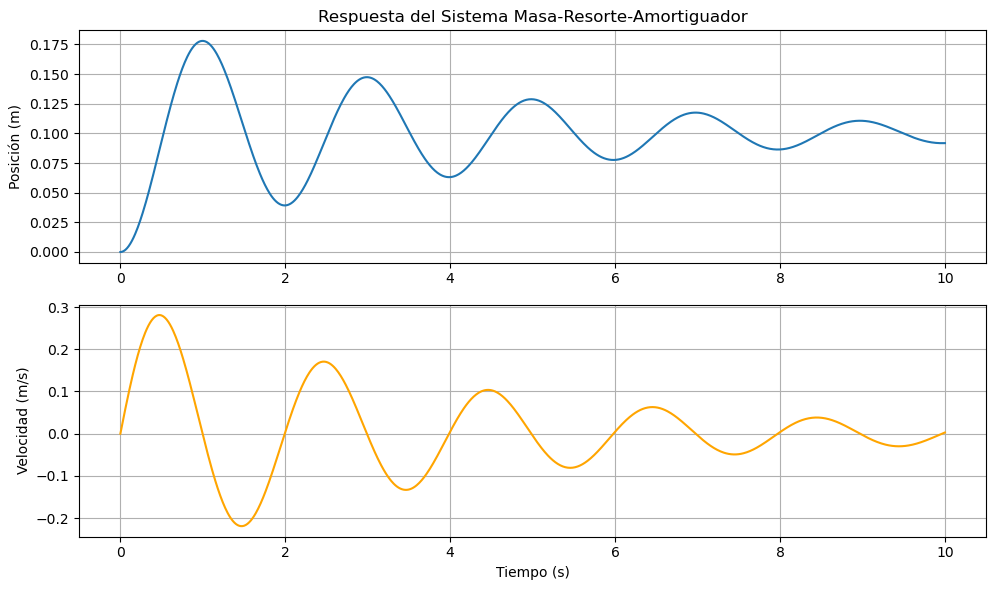

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parámetros del sistema masa-resorte-amortiguador
m = 1.0  # masa (kg)
k = 10.0  # constante del resorte (N/m)
c = 0.5  # coeficiente de amortiguamiento (Ns/m)

# Función que define la ecuación diferencial: dx/dt = [x1', x2'] donde x1 = x, x2 = x'
def system(state, t, m, k, c, F):
    x, v = state
    dxdt = v
    dvdt = (F - c * v - k * x) / m
    return [dxdt, dvdt]

# Condiciones iniciales: posición y velocidad
x0 = [0.0, 0.0]  # x(0) = 0, v(0) = 0

# Tiempo de simulación
t = np.linspace(0, 10, 1000)

# Entrada: fuerza constante (step input)
F = 1.0  # Fuerza aplicada (N)

# Resolver la ODE
sol = odeint(system, x0, t, args=(m, k, c, F))

# Extraer posición y velocidad
x = sol[:, 0]
v = sol[:, 1]

# Graficar la respuesta
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, x, label='Posición x(t)')
plt.title('Respuesta del Sistema Masa-Resorte-Amortiguador')
plt.ylabel('Posición (m)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, v, label='Velocidad v(t)', color='orange')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import sys
import numpy as np
from PyQt6.QtWidgets import (QApplication, QMainWindow, QWidget, QVBoxLayout, 
                             QHBoxLayout, QSlider, QLabel, QPushButton)
from PyQt6.QtCore import QTimer, Qt
import pyqtgraph as pg

class MRASimulator(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("Simulador MRA - Rango K [0-10]")
        
        self.m, self.b, self.k_phys = 1.0, 0.5, 2.0
        self.dt = 0.02 
        self.state = np.array([4.0, 0.0]) 
        self.K = np.array([5.0, 2.0]) 
        self.pos_history = []
        
        self.init_ui()
        self.update_labels()
        
        self.timer = QTimer()
        self.timer.timeout.connect(self.update_physics)
        self.timer.start(20)

    def init_ui(self):
        central_widget = QWidget()
        self.setCentralWidget(central_widget)
        main_layout = QHBoxLayout(central_widget)

        self.canvas = pg.GraphicsLayoutWidget()
        self.view = self.canvas.addViewBox()
        self.view.setAspectLocked(True)
        self.view.setRange(xRange=[-2, 2], yRange=[-5, 5], disableAutoRange=True)
        self.view.addItem(pg.InfiniteLine(pos=0, angle=0, pen=pg.mkPen('w', style=Qt.PenStyle.DashLine)))
        self.rect_masa = pg.ScatterPlotItem(size=40, brush=pg.mkBrush('r'), symbol='s')
        self.view.addItem(self.rect_masa)
        main_layout.addWidget(self.canvas, stretch=1)

        right_layout = QVBoxLayout()
        self.plot_pos = pg.PlotWidget(title="Posición vs Tiempo")
        self.plot_pos.setYRange(-5, 5)
        self.curve_pos = self.plot_pos.plot(pen='y')
        right_layout.addWidget(self.plot_pos)

        # K1 [0.0 - 10.0]
        right_layout.addWidget(QLabel("Control K1 (Rigidez):"))
        k1_layout = QHBoxLayout()
        self.slider_k1 = QSlider(Qt.Orientation.Horizontal)
        self.slider_k1.setRange(0, 100) # 100 pasos
        self.slider_k1.setValue(50)    # Inicial en 5.0
        self.slider_k1.valueChanged.connect(self.update_k)
        self.label_k1_val = QLabel("5.0")
        k1_layout.addWidget(self.slider_k1)
        k1_layout.addWidget(self.label_k1_val)
        right_layout.addLayout(k1_layout)

        # K2 [0.0 - 10.0]
        right_layout.addWidget(QLabel("Control K2 (Amortiguamiento):"))
        k2_layout = QHBoxLayout()
        self.slider_k2 = QSlider(Qt.Orientation.Horizontal)
        self.slider_k2.setRange(0, 100)
        self.slider_k2.setValue(20)    # Inicial en 2.0
        self.slider_k2.valueChanged.connect(self.update_k)
        self.label_k2_val = QLabel("2.0")
        k2_layout.addWidget(self.slider_k2)
        k2_layout.addWidget(self.label_k2_val)
        right_layout.addLayout(k2_layout)

        self.btn_reset = QPushButton("REINICIAR")
        self.btn_reset.setStyleSheet("background-color: #2c3e50; color: white; font-weight: bold; padding: 10px;")
        self.btn_reset.clicked.connect(self.reset_simulation)
        right_layout.addWidget(self.btn_reset)

        main_layout.addLayout(right_layout, stretch=1)

    def update_k(self):
        self.K[0] = self.slider_k1.value() / 10.0
        self.K[1] = self.slider_k2.value() / 10.0
        self.update_labels()

    def update_labels(self):
        self.label_k1_val.setText(f"{self.K[0]:.1f}")
        self.label_k2_val.setText(f"{self.K[1]:.1f}")

    def reset_simulation(self):
        self.state = np.array([4.0, 0.0])
        self.pos_history = []
        self.curve_pos.setData([])
    
    def update_physics(self):
        u = -np.dot(self.K, self.state)
        y, v = self.state
        dv = (u - self.b*v - self.k_phys*y) / self.m
        self.state[0] += v * self.dt
        self.state[1] += dv * self.dt
        self.rect_masa.setData(x=[0], y=[self.state[0]])
        self.pos_history.append(self.state[0])
        if len(self.pos_history) > 1000: self.pos_history.pop(0)
        self.curve_pos.setData(self.pos_history)

if __name__ == "__main__":
    app = QApplication(sys.argv)
    sim = MRASimulator()
    sim.show()
    sys.exit(app.exec())